In [1]:
# import sys, os

import numpy as np
# Note that the path ./Albedo_project/data_processing is now in the path
import xarray as xr
from cloudpathlib import AnyPath
import matplotlib.pyplot as plt
import datetime

# Local Imports
curdir = os.getcwd()
print(curdir+"../data_processing")
sys.path.insert(0, curdir+"/../data_processing")
sys.path.insert(0, curdir+"/../visualization")
from ceres_ebaf import apply_spatial_weights, create_hemisphere_data, apply_time_averaging
import ceres_ebaf_plotting

fig_path = AnyPath("../../Figs")
current_month_folder="24Feb"
base_path = AnyPath("/Users/mawa7160/dev/data")

/Users/mawa7160/Library/CloudStorage/OneDrive-UCB-O365/Documents/GitHub/Hemispheric-Albedo-Project/Albedo_project/Notebooks../data_processing


# Start by loading the CERES EBAF data plotting the monthly mean of the solar flux
This below shows that CERES is using the at Earth measurement of the solar TSI

In [2]:
ebaf_file_path = base_path / "CERES"/ "EBAF" / "24Feb" / "CERES_EBAF-TOA_Ed4.2_Subset_200003-202311.nc"
ebaf_full_years = xr.open_dataset(ebaf_file_path)

sh_monthly = apply_spatial_weights(ebaf_full_years["solar_mon"],low_lat=-90, high_lat=0)
nh_monthly = apply_spatial_weights(ebaf_full_years["solar_mon"],low_lat=0, high_lat=90)
global_monthly = apply_spatial_weights(ebaf_full_years["solar_mon"],low_lat=-90, high_lat=90)

Text(0.5, 1.0, 'CERES EBAF Incoming Solar Monthly Data')

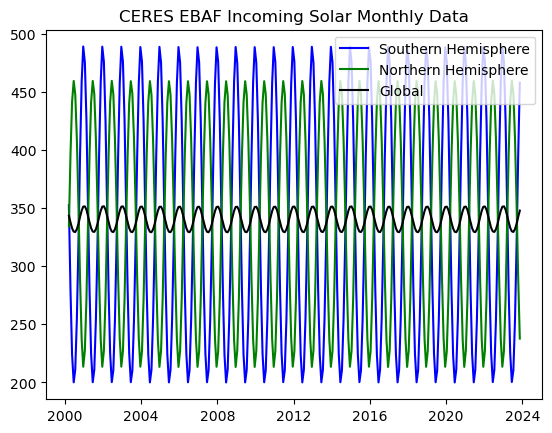

In [3]:
plt.plot(sh_monthly.time, sh_monthly, "b", label="Southern Hemisphere")
plt.plot(nh_monthly.time, nh_monthly, "g", label="Northern Hemisphere")
plt.plot(global_monthly.time, global_monthly, "k", label="Global")
plt.legend()
plt.title("CERES EBAF Incoming Solar Monthly Data")

# Now load the TSI data from TSIS and plot the monthly mean of the TSI data

In [4]:
tsis_file_path = base_path / "TSIS" / "tsis_tsi_L3_c24h_02_2024.txt"
tsis_raw_data = np.loadtxt(tsis_file_path, skiprows=133)

In [5]:
# Convert the date to a datetime object
tsis_days_str = tsis_raw_data[:,0].astype(str)
tsis_num_to_date = lambda x: datetime.datetime.strptime(str(x), "%Y%m%d.5")
tsis_func = np.vectorize(tsis_num_to_date)
tsis_days_raw = tsis_func(tsis_days_str)

# Select the data from the file
tsis_tsi_1au_raw = tsis_raw_data[:,4]
tsis_tsi_1au_std_raw = tsis_raw_data[:,8]
tsis_tsi_at_earth_raw = tsis_raw_data[:,9]
tsis_tsi_at_earth_std_raw = tsis_raw_data[:,13]
filter = tsis_tsi_1au_raw > 0

# Remove the data that is 0 for the TSI 1AU data field
tsis_tsi_1au_std = tsis_tsi_1au_std_raw[filter]
tsis_tsi_at_earth = tsis_tsi_at_earth_raw[filter]
tsis_tsi_at_earth_std = tsis_tsi_at_earth_std_raw[filter]
tsis_days = tsis_days_raw[filter]+datetime.timedelta(days=0.5)
tsis_tsi_1au = tsis_tsi_1au_raw[filter]

# Create a Xarray dataset from the data with tsis days as the time
tsis_data = xr.Dataset(
    {
        "tsi_1au": (["time"], tsis_tsi_1au),
        "tsi_1au_std": (["time"], tsis_tsi_1au_std),
        "tsi_at_earth": (["time"], tsis_tsi_at_earth),
        "tsi_at_earth_std": (["time"], tsis_tsi_at_earth_std),
    },
    coords={"time": tsis_days},
)

# Make a copy of the data with the raw data
tsis_data_raw = xr.Dataset(
    {
        "tsi_1au": (["time"], tsis_tsi_1au_raw),
        "tsi_1au_std": (["time"], tsis_tsi_1au_std_raw),
        "tsi_at_earth": (["time"], tsis_tsi_at_earth_raw),
        "tsi_at_earth_std": (["time"], tsis_tsi_at_earth_std_raw),
    },
    coords={"time": tsis_days_raw},
)

# First is the TSI data corrected to 1AU

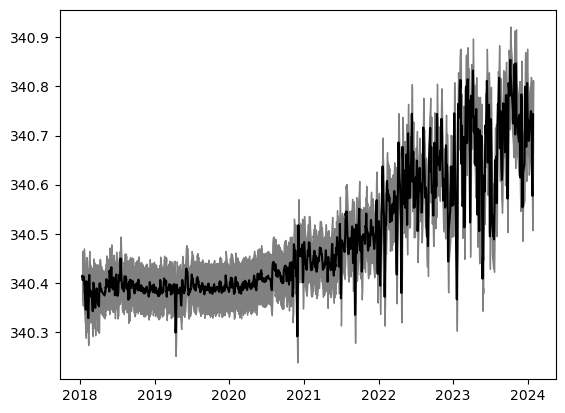

In [6]:
# plot the envelope of the tsi std 1 au as a gray area at opacity 0.5
plt.fill_between(tsis_days, tsis_tsi_1au/4+tsis_tsi_1au_std/4, tsis_tsi_1au/4-tsis_tsi_1au_std/4, color="gray")

# plot the TSI data for 1AU in black  
plt.plot(tsis_days, tsis_tsi_1au/4, color="black")

# Next is the TSI data at Earth

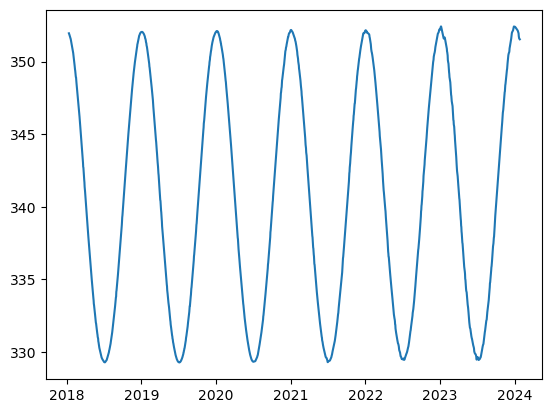

In [7]:
plt.plot(tsis_days, tsis_tsi_at_earth/4)

# Now compare the TSIS data to the CERES data on a monthly basis

In [8]:
# Take the monthly mean of the TSI data and set the time to be the 15th of the month
tsis_monthly = tsis_data.resample(time="1M").mean()
# Remove the first entry as it is not a full month
tsis_monthly = tsis_monthly.sel(time=slice("2018-02-15", "2023-12-15"))

# There is a bias 
## TODO look into this bias

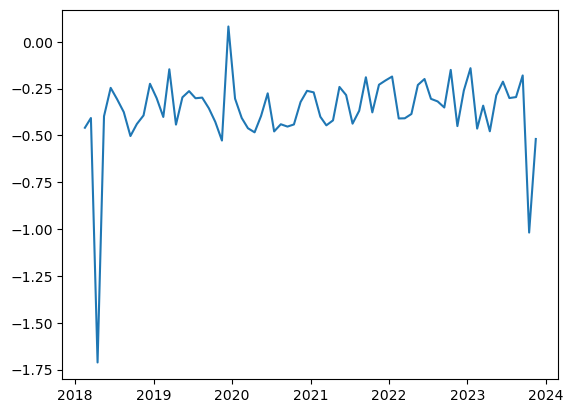

In [9]:
global_monthly_ceres_match = global_monthly.sel(time=slice("2018-02-01", "2023-12-01"))
# take the difference between the TSI and CERES 
diff_tsis_ceres = global_monthly_ceres_match.values - tsis_monthly.tsi_at_earth/4
plt.plot(global_monthly_ceres_match.time, diff_tsis_ceres)

# Try looking at the true interest area which is the annual average

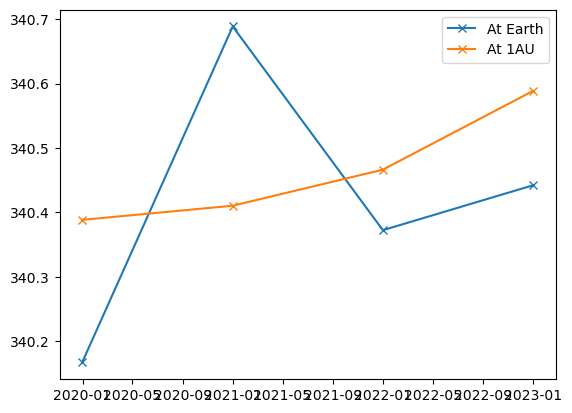

In [10]:
tsis_yearly = tsis_data.resample(time="1Y").mean()
# Drop the first and last year as they are not full years
tsis_yearly = tsis_yearly.sel(time=slice("2019-01-01", "2023-01-01"))
plt.plot(tsis_yearly.time, tsis_yearly.tsi_at_earth/4, "-x", label="At Earth")
plt.plot(tsis_yearly.time, tsis_yearly.tsi_1au/4, "-x", label="At 1AU")
plt.legend()

In [11]:
global_yearly = global_monthly.resample(time="1Y").mean()
# Drop to match the TSI data
global_yearly = global_yearly.sel(time=slice("2019-01-01", "2023-01-01"))

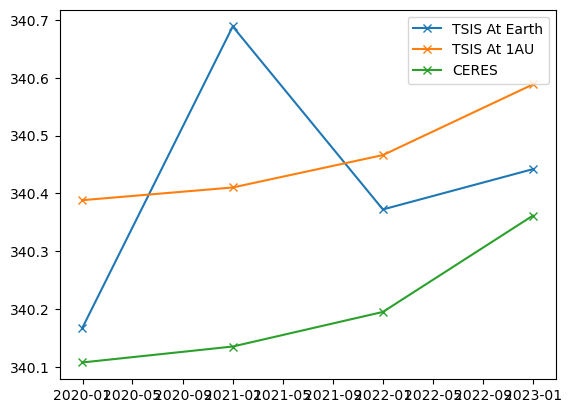

In [12]:
plt.plot(tsis_yearly.time, tsis_yearly.tsi_at_earth/4, "-x", label="TSIS At Earth")
plt.plot(tsis_yearly.time, tsis_yearly.tsi_1au/4, "-x", label="TSIS At 1AU")
plt.plot(tsis_yearly.time, global_yearly, "-x", label="CERES")
plt.legend()

In [13]:
matts_method_ceres = create_hemisphere_data(ebaf_full_years["solar_mon"])
matts_method_ceres = matts_method_ceres.sel(year=slice("2018-02-01", "2023-12-01"))

tsis_monthly_trim = tsis_monthly.sel(time=slice("2019-01-01", "2023-01-01"))
matts_method_tsis = apply_time_averaging(tsis_monthly_trim.tsi_at_earth/4, averaging_method=1)
matts_method_tsis_1au = apply_time_averaging(tsis_monthly_trim.tsi_1au/4, averaging_method=1)

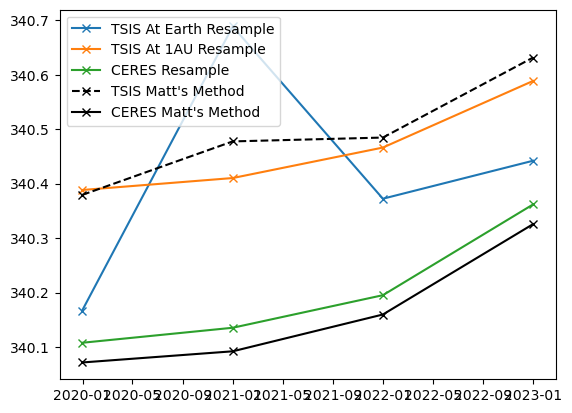

In [14]:
plt.plot(tsis_yearly.time, tsis_yearly.tsi_at_earth/4, "-x", label="TSIS At Earth Resample")
plt.plot(tsis_yearly.time, tsis_yearly.tsi_1au/4, "-x", label="TSIS At 1AU Resample")
plt.plot(tsis_yearly.time, global_yearly, "-x", label="CERES Resample")
plt.plot(tsis_yearly.time, matts_method_tsis, "k--x", label="TSIS Matt's Method")
plt.plot(tsis_yearly.time, matts_method_ceres["global"], "k-x", label="CERES Matt's Method")
plt.legend()

# To try and figure out where these differences are coming from let's do 2 things:
1. look at the solar composite data to see if there is a bias in the data there
2. From the TSIS 6 hour data, calculate a true annual average and compare that to the resampled calculation

## 1. Compare to the solar composite data

In [15]:
# Load the solar composite data
solar_composite_path = base_path / "TSI_Composite" / "TSI_Composite-SIST.txt"
tsi_comp = np.loadtxt(solar_composite_path, skiprows=36)

tsi_comp_julian_day = tsi_comp[:, 0]
tsi_comp_tsi = tsi_comp[:, 1]
tsi_comp_std = tsi_comp[:, 2]

In [16]:
def julian_day_to_datetime(julian_dates):
    # The Julian day for the start of the Julian calendar is 1721423.5
    julian_start = 1721423.5
    
    # If the input is a single Julian date, convert it to a one-element array
    if isinstance(julian_dates, (int, float)):
        julian_dates = np.array([julian_dates])
    
    # Calculate the number of days from the start of the Julian calendar to the given Julian dates
    days_since_julian_start = julian_dates - julian_start
    
    # Convert the days to seconds
    seconds_since_julian_start = days_since_julian_start * 86400  # 60 seconds * 60 minutes * 24 hours
    
    # Create timedelta objects with the calculated seconds
    deltas = [datetime.timedelta(seconds=seconds) for seconds in seconds_since_julian_start]
    
    # Create datetime objects representing the dates and times
    datetime_objs = [datetime.datetime(1, 1, 1) + delta for delta in deltas]
    
    # If only one Julian date was provided, return a single datetime object
    if len(datetime_objs) == 1:
        return datetime_objs[0]
    
    return np.array(datetime_objs)

In [17]:
# Create an xarray dataset from the solar composite data
tsi_comp_time = julian_day_to_datetime(tsi_comp_julian_day)
tsi_comp_data = xr.Dataset(
    {
        "tsi": (["time"], tsi_comp_tsi),
        "tsi_std": (["time"], tsi_comp_std),
    },
    coords={"time": tsi_comp_time},
)

In [18]:
# Resample the solar composite data to monthly and trim to match the TSIS data
tsi_comp_monthly = tsi_comp_data.resample(time="1M").mean()
tsi_comp_monthly = tsi_comp_monthly.sel(time=slice("2019-01-01", "2023-01-01"))


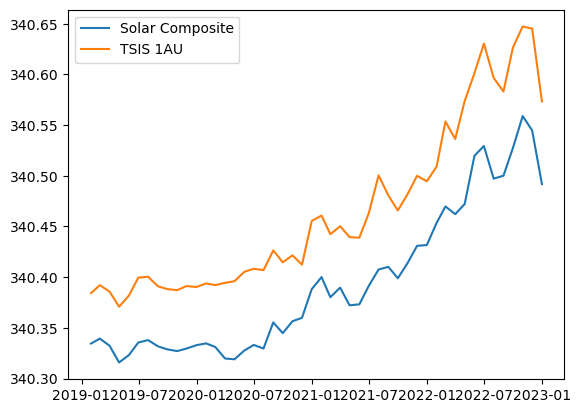

In [19]:
# Compare the TSIS monthly 1 au data to the solar composite data
plt.plot(tsi_comp_monthly.time, tsi_comp_monthly.tsi/4, label="Solar Composite")
plt.plot(tsis_monthly_trim.time, tsis_monthly_trim.tsi_1au/4, label="TSIS 1AU")
plt.legend()

In [20]:
# Calculate the annual average of the solar composite monthly data
tsi_comp_yearly = tsi_comp_monthly.resample(time="1Y").mean()
# Calculate the annual average of the TSI comp monthly data using the apply_time_averaging function
tsi_comp_yearly_matt = apply_time_averaging(tsi_comp_monthly.tsi/4, averaging_method=1)

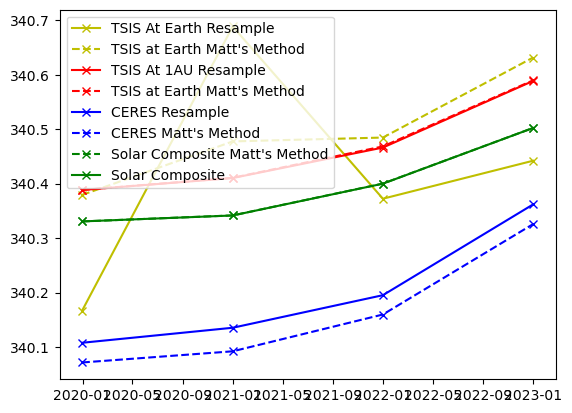

In [21]:
plt.plot(tsis_yearly.time, tsis_yearly.tsi_at_earth/4, "y-x", label="TSIS At Earth Resample")
plt.plot(tsis_yearly.time, matts_method_tsis, "y--x", label="TSIS at Earth Matt's Method")

plt.plot(tsis_yearly.time, tsis_yearly.tsi_1au/4, "r-x", label="TSIS At 1AU Resample")
plt.plot(tsis_yearly.time, matts_method_tsis_1au, "r--x", label="TSIS at Earth Matt's Method")

plt.plot(tsis_yearly.time, global_yearly, "b-x", label="CERES Resample")
plt.plot(tsis_yearly.time, matts_method_ceres["global"], "b--x", label="CERES Matt's Method")

# plot the solar composite data
plt.plot(tsis_yearly.time, tsi_comp_yearly_matt, "g--x", label="Solar Composite Matt's Method")
plt.plot(tsis_yearly.time, tsi_comp_yearly.tsi/4, "g-x", label="Solar Composite")

plt.legend()

# 2. Look at the TSIS 6 hour data

In [22]:
# Load the TSIS 6 hour data
tsis_6h_file_path = base_path / "TSIS" / "tsis_tsi_L3_c06h_02_2024.txt"
tsis_6h_raw_data = np.loadtxt(tsis_6h_file_path, skiprows=133)

In [23]:
# Convert the julian date to a datetime object
tsis_6h_days_julian = tsis_6h_raw_data[:,1]
tsis_6h_days_julian_avg = tsis_6h_raw_data[:,2]

tsis_6h_days_raw = julian_day_to_datetime(tsis_6h_days_julian)
tsis_6h_days_avg_raw = julian_day_to_datetime(tsis_6h_days_julian_avg)


In [24]:
# Select the data from the file
tsis_6h_tsi_1au_raw = tsis_6h_raw_data[:,4]
tsis_6h_tsi_1au_std_raw = tsis_6h_raw_data[:,8]
tsis_6h_tsi_at_earth_raw = tsis_6h_raw_data[:,9]
tsis_6h_tsi_at_earth_std_raw = tsis_6h_raw_data[:,13]
filter = tsis_6h_tsi_1au_raw > 0

# Remove the data that is 0 for the TSI 1AU data field
tsis_6h_tsi_1au_std = tsis_6h_tsi_1au_std_raw[filter]
tsis_6h_tsi_at_earth = tsis_6h_tsi_at_earth_raw[filter]
tsis_6h_tsi_at_earth_std = tsis_6h_tsi_at_earth_std_raw[filter]
tsis_6h_days = tsis_6h_days_raw[filter]
tsis_6h_tsi_1au = tsis_6h_tsi_1au_raw[filter]

In [25]:
# Create an xarray dataset from the 6 hour data 
tsis_6h_data = xr.Dataset(
    {
        "tsi_1au": (["time"], tsis_6h_tsi_1au),
        "tsi_1au_std": (["time"], tsis_6h_tsi_1au_std),
        "tsi_at_earth": (["time"], tsis_6h_tsi_at_earth),
        "tsi_at_earth_std": (["time"], tsis_6h_tsi_at_earth_std),
    },
    coords={"time": tsis_6h_days},
)

# Create an xarray dataset from the 6 hour data with the raw data
tsis_6h_data_raw = xr.Dataset(
    {
        "tsi_1au": (["time"], tsis_6h_tsi_1au_raw),
        "tsi_1au_std": (["time"], tsis_6h_tsi_1au_std_raw),
        "tsi_at_earth": (["time"], tsis_6h_tsi_at_earth_raw),
        "tsi_at_earth_std": (["time"], tsis_6h_tsi_at_earth_std_raw),
    },
    coords={"time": tsis_6h_days_raw},
)

In [26]:
# Trim the 6 hour data to start January 1 2019 after 12 pm
tsis_6h_data_trim = tsis_6h_data.sel(time=slice("2019-01-01T12:00:00", "2023-01-02T12:00:00"))
tsis_6h_data_trim

<xarray.Dataset>
Dimensions:           (time: 4295)
Coordinates:
  * time              (time) datetime64[ns] 2019-01-01T15:00:00 ... 2023-01-0...
Data variables:
    tsi_1au           (time) float64 1.362e+03 1.362e+03 ... 1.362e+03 1.362e+03
    tsi_1au_std       (time) float64 0.1886 0.1892 0.188 ... 0.2517 0.2506 0.252
    tsi_at_earth      (time) float64 1.408e+03 1.408e+03 ... 1.409e+03 1.409e+03
    tsi_at_earth_std  (time) float64 0.195 0.1958 0.1946 ... 0.2591 0.2604

In [27]:
data_2019 = tsis_6h_data.sel(time=slice("2019-01-01T12:00:00", "2020-01-02T18:00:00"))
#print(f"Start time for 2019 is {data_2019.time[0]} and end time is {data_2019.time[-1]}")
data_2020 = tsis_6h_data.sel(time=slice("2020-01-01T18:00:00", "2021-01-01T00:00:00"))
#print(f"Start time for 2020 is {data_2020.time[0]} and end time is {data_2020.time[-1]}")
data_2021 = tsis_6h_data.sel(time=slice("2021-01-01T00:00:00", "2022-01-01T06:00:00"))
#print(f"Start time for 2021 is {data_2021.time[0]} and end time is {data_2021.time[-1]}")
data_2022 = tsis_6h_data.sel(time=slice("2022-01-01T18:00:00", "2023-01-01T12:00:00"))
#print(f"Start time for 2022 is {data_2022.time[0]} and end time is {data_2022.time[-1]}")

In [28]:
data2019_mean = data_2019.mean()
data2020_mean = data_2020.mean()
data2021_mean = data_2021.mean()
data2022_mean = data_2022.mean()

In [29]:
tsis_6h_accurate = [data2019_mean, data2020_mean, data2021_mean, data2022_mean]
tsis_6h_accurate = xr.concat(tsis_6h_accurate, dim="time")

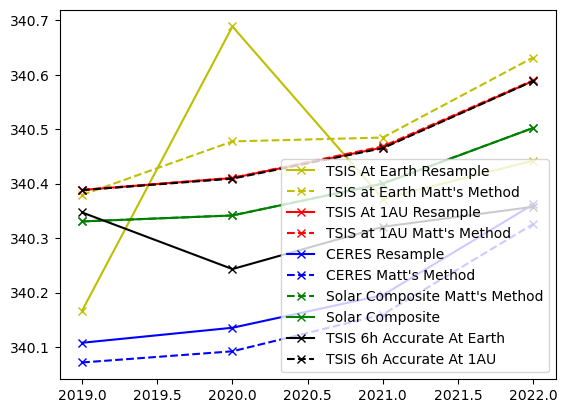

In [30]:
plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_at_earth/4, "y-x", label="TSIS At Earth Resample")
plt.plot(matts_method_tsis_1au.year, matts_method_tsis, "y--x", label="TSIS at Earth Matt's Method")

plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_1au/4, "r-x", label="TSIS At 1AU Resample")
plt.plot(matts_method_tsis_1au.year, matts_method_tsis_1au, "r--x", label="TSIS at 1AU Matt's Method")

plt.plot(matts_method_tsis_1au.year, global_yearly, "b-x", label="CERES Resample")
plt.plot(matts_method_tsis_1au.year, matts_method_ceres["global"], "b--x", label="CERES Matt's Method")

# plot the solar composite data
plt.plot(matts_method_tsis_1au.year, tsi_comp_yearly_matt, "g--x", label="Solar Composite Matt's Method")
plt.plot(matts_method_tsis_1au.year, tsi_comp_yearly.tsi/4, "g-x", label="Solar Composite")

plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate.tsi_at_earth/4, "k-x", label="TSIS 6h Accurate At Earth")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate.tsi_1au/4, "k--x", label="TSIS 6h Accurate At 1AU")

plt.legend()

# Fill the gaps in the 6h data

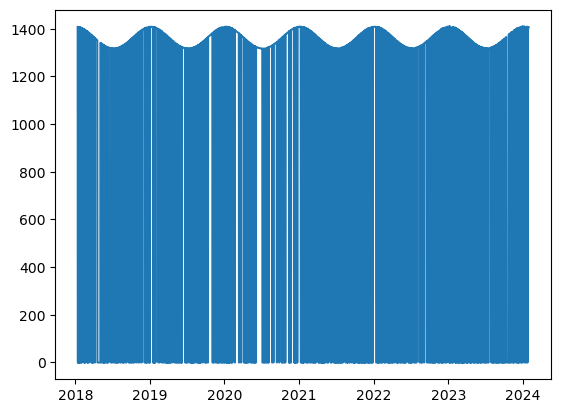

In [31]:
# The TSIS 6 hour data has gaps that are filled by the value 0. This is not a good representation of the data
# let's try to fill the gaps with a linear interpolation between the two closest points
# To do this let's first change any 0 values to NaN

#First let's see the gaps in the data
plt.plot(tsis_6h_data_raw.time, tsis_6h_data_raw.tsi_at_earth)

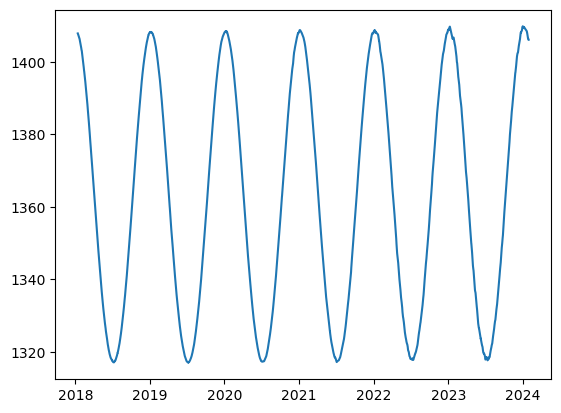

In [32]:
tsis_6h_data_interp = tsis_6h_data_raw.where(tsis_6h_data_raw > 0)
tsis_6h_data_interp = tsis_6h_data_interp.interpolate_na(dim="time", method="linear")
plt.plot(tsis_6h_data_interp.time, tsis_6h_data_interp.tsi_at_earth)

In [33]:
data_2019_interp = tsis_6h_data_interp.sel(time=slice("2019-01-01T12:00:00", "2020-01-01T18:00:00"))
data_2020_interp = tsis_6h_data_interp.sel(time=slice("2020-01-01T18:00:00", "2021-01-01T00:00:00"))
data_2021_interp = tsis_6h_data_interp.sel(time=slice("2021-01-01T00:00:00", "2022-01-01T06:00:00"))
data_2022_interp = tsis_6h_data_interp.sel(time=slice("2022-01-01T06:00:00", "2023-01-01T12:00:00"))

data2019_interp_mean = data_2019_interp.mean()
data2020_interp_mean = data_2020_interp.mean()
data2021_interp_mean = data_2021_interp.mean()
data2022_interp_mean = data_2022_interp.mean()

tsis_6h_accurate_interp = [data2019_interp_mean, data2020_interp_mean, data2021_interp_mean, data2022_interp_mean]
tsis_6h_accurate_interp = xr.concat(tsis_6h_accurate_interp, dim="time")

# Plot the interpolated tsis 6h data against the original tsis 6h data
#plt.plot(tsis_6h_data_interp.time, tsis_6h_data_interp.tsi_at_earth, "-x", label="Interpolated")
#plt.plot(tsis_6h_data.time, tsis_6h_data.tsi_at_earth, "-o", label="Original")
#plt.legend()


In [34]:
data_2022_interp.time.shape

(1461,)

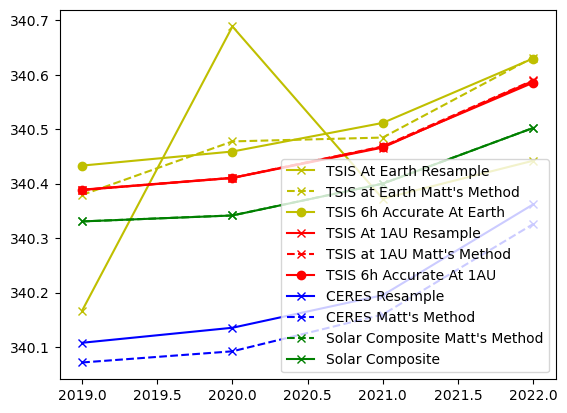

In [35]:
plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_at_earth/4, "y-x", label="TSIS At Earth Resample")
plt.plot(matts_method_tsis_1au.year, matts_method_tsis, "y--x", label="TSIS at Earth Matt's Method")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_at_earth/4, "y-o", label="TSIS 6h Accurate At Earth")

plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_1au/4, "r-x", label="TSIS At 1AU Resample")
plt.plot(matts_method_tsis_1au.year, matts_method_tsis_1au, "r--x", label="TSIS at 1AU Matt's Method")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_1au/4, "r-o", label="TSIS 6h Accurate At 1AU")

plt.plot(matts_method_tsis_1au.year, global_yearly, "b-x", label="CERES Resample")
plt.plot(matts_method_tsis_1au.year, matts_method_ceres["global"], "b--x", label="CERES Matt's Method")

# plot the solar composite data
plt.plot(matts_method_tsis_1au.year, tsi_comp_yearly_matt, "g--x", label="Solar Composite Matt's Method")
plt.plot(matts_method_tsis_1au.year, tsi_comp_yearly.tsi/4, "g-x", label="Solar Composite")


plt.legend()

# Test out filling the tsis daily at earth data

In [36]:
tsis_1d_data_interp = tsis_data_raw.where(tsis_data_raw > 0)
tsis_1d_data_interp = tsis_1d_data_interp.interpolate_na(dim="time", method="linear")

tsis_1d_data_interp_monthly = tsis_1d_data_interp.resample(time="1M").mean()
tsis_1d_data_interp_monthly = tsis_1d_data_interp_monthly.sel(time=slice("2019-01-01", "2023-01-01"))

tsis_1d_data_interp_yearly_resample = tsis_1d_data_interp_monthly.resample(time="1Y").mean()
tsis_1d_data_interp_yearly_matt_at_earth = apply_time_averaging(tsis_1d_data_interp_monthly.tsi_at_earth/4, averaging_method=2)
tsis_1d_data_interp_yearly_matt_at_1au = apply_time_averaging(tsis_1d_data_interp_monthly.tsi_1au/4, averaging_method=1)

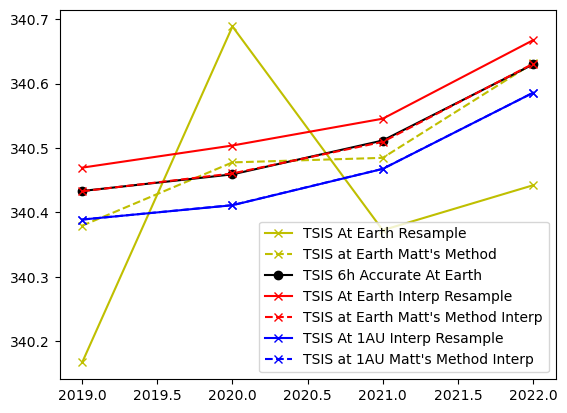

In [37]:
plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_at_earth/4, "y-x", label="TSIS At Earth Resample")
plt.plot(matts_method_tsis_1au.year, matts_method_tsis, "y--x", label="TSIS at Earth Matt's Method")

plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_at_earth/4, "k-o", label="TSIS 6h Accurate At Earth")

plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_resample.tsi_at_earth/4, "r-x", label="TSIS At Earth Interp Resample")
plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_matt_at_earth, "r--x", label="TSIS at Earth Matt's Method Interp" )

plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_resample.tsi_1au/4, "b-x", label="TSIS At 1AU Interp Resample")
plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_matt_at_1au, "b--x", label="TSIS at 1AU Matt's Method Interp")

plt.legend()

# Compare filled and not filled data
## First for the Daily data - Using the Resample method from xarray

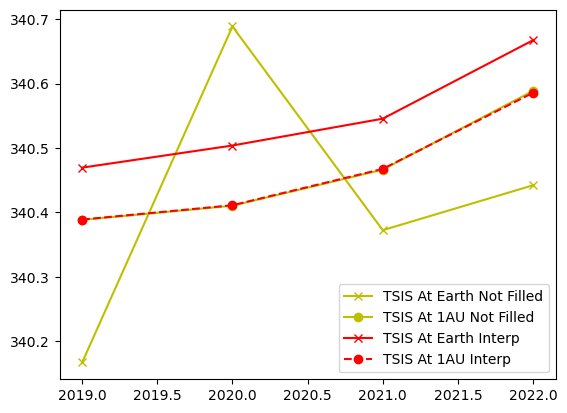

In [38]:
# Plot the annual filled and not filled from 1d data
plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_at_earth/4, "y-x", label="TSIS At Earth Not Filled")
plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_1au/4, "y-o", label="TSIS At 1AU Not Filled")

plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_resample.tsi_at_earth/4, "r-x", label="TSIS At Earth Interp")
plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_resample.tsi_1au/4, "r--o", label="TSIS At 1AU Interp")

plt.legend()

## Now for the 6h data

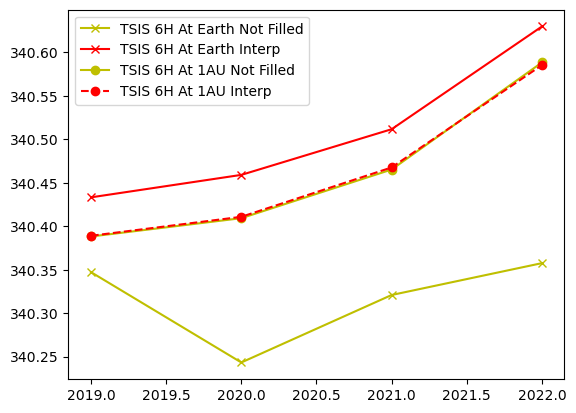

In [39]:
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate.tsi_at_earth/4, "y-x", label="TSIS 6H At Earth Not Filled")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_at_earth/4, "r-x", label="TSIS 6H At Earth Interp")

plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate.tsi_1au/4, "y-o", label="TSIS 6H At 1AU Not Filled")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_1au/4, "r--o", label="TSIS 6H At 1AU Interp")

plt.legend()

# Compare 1AU data for the 6h and 1d data

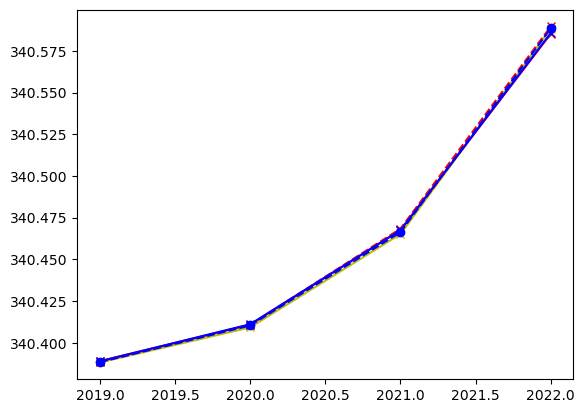

In [40]:
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate.tsi_1au/4, "y-x", label="TSIS 6H At 1AU Not Filled")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_1au/4, "r-x", label="TSIS 6H At 1AU Interp")
plt.plot(matts_method_tsis_1au.year, matts_method_tsis_1au, "r--x", label="TSIS 1D At 1AU Matt's Method")

plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_resample.tsi_1au/4, "b-x", label="TSIS 1D At 1AU Interp")
plt.plot(matts_method_tsis_1au.year, tsis_yearly.tsi_1au/4, "b--o", label="TSIS 1D At 1AU Not Filled")

# Comparison of the CERES, TSIS, and Solar Composite data

Text(0.5, 1.0, 'Comparison of CERES, TSIS, and Solar Composite TSI Annual Averaged Data')

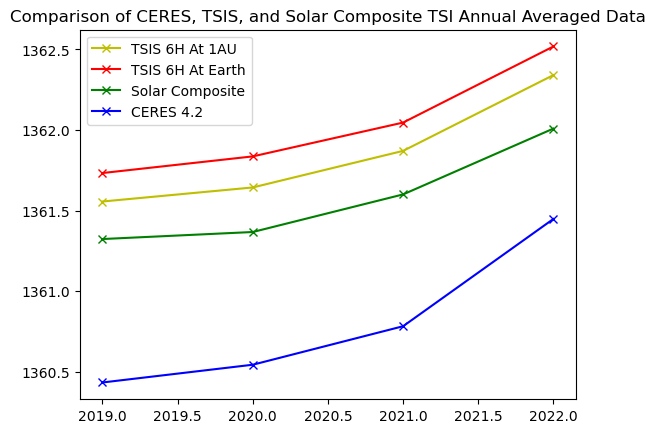

In [54]:
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_1au, "y-x", label="TSIS 6H At 1AU")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_at_earth, "r-x", label="TSIS 6H At Earth")
plt.plot(matts_method_tsis_1au.year, tsi_comp_yearly.tsi, "g-x", label="Solar Composite")
plt.plot(matts_method_tsis_1au.year, global_yearly*4, "b-x", label="CERES 4.2")

plt.legend()
plt.title("Comparison of CERES, TSIS, and Solar Composite TSI Annual Averaged Data")

# Compare a 365.25 day year to a 365 day year using the 6 hour filled data

In [42]:
# resample the tsis6h data to a yearly average
tsis_6h_accurate_interp_yearly = tsis_6h_data_interp.sel(time=slice("2019-01-01T12:00:00", "2023-01-01T00:00:00"))
tsis_6h_accurate_interp_yearly = tsis_6h_accurate_interp_yearly.resample(time="1Y").mean()


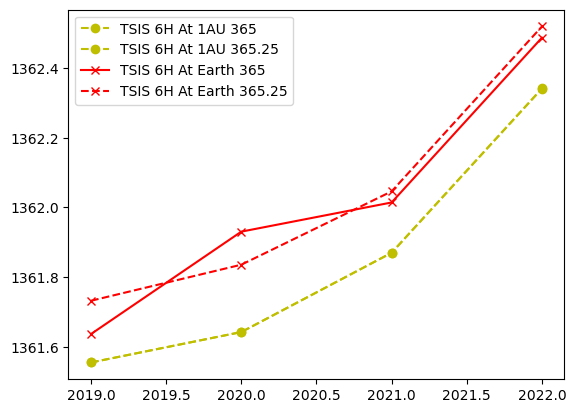

In [43]:
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp_yearly.tsi_1au, "y--o", label="TSIS 6H At 1AU 365")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_1au, "y--o", label="TSIS 6H At 1AU 365.25")

plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp_yearly.tsi_at_earth, "r-x", label="TSIS 6H At Earth 365")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_at_earth, "r--x", label="TSIS 6H At Earth 365.25")

plt.legend()

# Let's now compare my method vs standard resampling

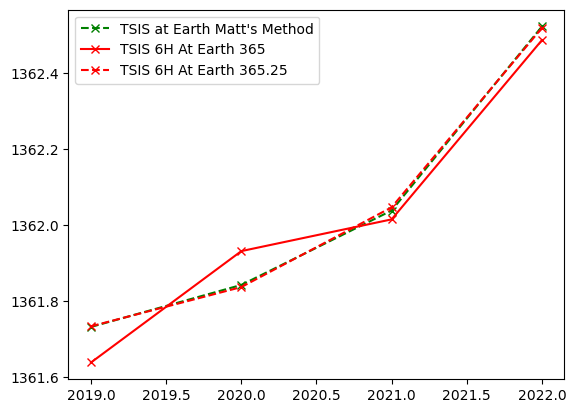

In [44]:
plt.plot(matts_method_tsis_1au.year, tsis_1d_data_interp_yearly_matt_at_earth*4, "g--x", label="TSIS at Earth Matt's Method")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp_yearly.tsi_at_earth, "r-x", label="TSIS 6H At Earth 365")
plt.plot(matts_method_tsis_1au.year, tsis_6h_accurate_interp.tsi_at_earth, "r--x", label="TSIS 6H At Earth 365.25")

plt.legend()

# Now let's createa longer series of the data from the composite then compare to CERES

In [45]:
# First let create monlthy data from the composite
tsi_comp_monthly = tsi_comp_data.resample(time="1M").mean()
tsi_comp_monthly = tsi_comp_monthly.sel(time=slice("2000-01-01", "2023-12-31"))

In [46]:
# Now let's create a yearly average from the monthly data 
tsi_comp_yearly_resample = tsi_comp_monthly.resample(time="1Y").mean()
tsi_comp_yearly_matt = apply_time_averaging(tsi_comp_monthly.tsi/4, averaging_method=2)

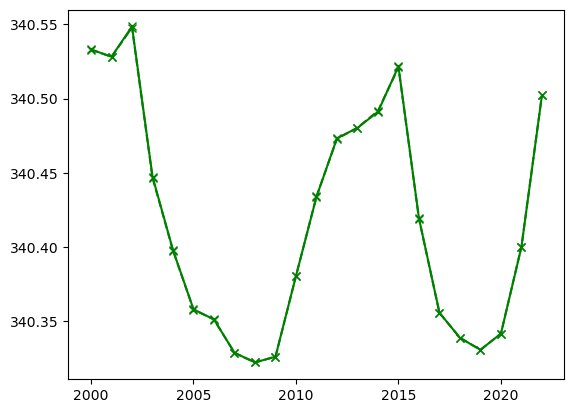

In [47]:
plt.plot(tsi_comp_yearly_matt.year, tsi_comp_yearly_resample.tsi[:-1]/4, "g-x", label="Solar Composite Resample")
plt.plot(tsi_comp_yearly_matt.year, tsi_comp_yearly_matt, "g--x", label="Solar Composite Matt's Method")

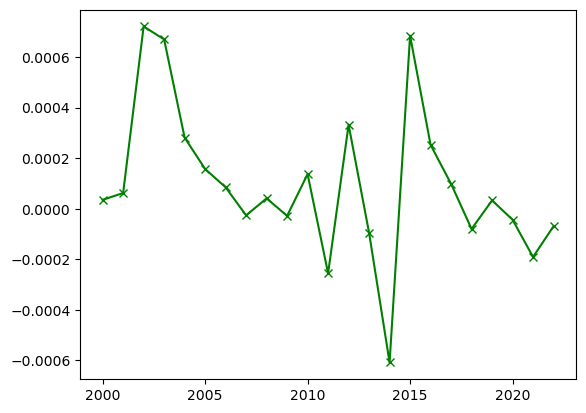

In [48]:
# calculate and plot the difference
difference = tsi_comp_yearly_resample.tsi[:-1]/4-tsi_comp_yearly_matt.values
plt.plot(tsi_comp_yearly_matt.year, difference, "g-x", label="Solar Composite Resample")

In [49]:
# calculate a ceres yearly average
ceres_yearly = global_monthly.resample(time="1Y").mean()
ceres_yearly

<xarray.DataArray 'solar_mon' (time: 24)>
array([338.37110499, 340.31246961, 340.32809258, 340.21444837,
       340.17362513, 340.11645303, 340.10671869, 340.08492836,
       340.08038831, 340.07472781, 340.12931404, 340.18249815,
       340.22769921, 340.22400553, 340.25380953, 340.28797233,
       340.19523121, 340.13296478, 340.11612158, 340.10799944,
       340.13556594, 340.19532762, 340.36188976, 339.47464651])
Coordinates:
  * time     (time) datetime64[ns] 2000-12-31 2001-12-31 ... 2023-12-31

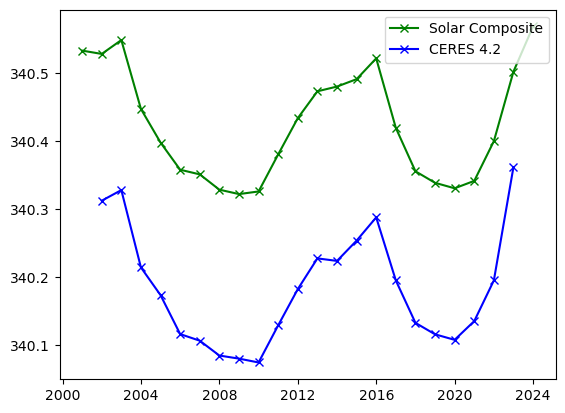

In [55]:
ceres_avg = ceres_yearly[1:-1].mean()
tsi_comp_avg = (tsi_comp_yearly_resample.tsi/4).mean()
plt.plot(tsi_comp_yearly_resample.time, tsi_comp_yearly_resample.tsi/4, "g-x", label="Solar Composite")
plt.plot(tsi_comp_yearly_resample.time[1:-1], ceres_yearly[1:-1], "b-x", label="CERES 4.2")
plt.legend()

In [51]:
print(f"The average TSI from the solar composite is {tsi_comp_avg} and the average TSI from CERES is {ceres_avg}")

The average TSI from the solar composite is <xarray.DataArray 'tsi' ()>
array(340.42412336) and the average TSI from CERES is <xarray.DataArray 'solar_mon' ()>
array(340.18373868)
